# Building LLM AI Flows

We categorise LLM-based systems by the reasoning and interaction steps they perform.

**Types of LLM systems**

1. **Single-shot (one-pass) systems** \
   One prompt produces one response in a single forward pass. The system is stateless, with no intermediate structure. It is simple but weak at long-horizon or compositional reasoning and offers no error recovery.

2. **Multi-step chaining (pipeline-style) systems** \
   Tasks are manually decomposed into sequential LLM calls, where each step feeds into the next. Control flow is deterministic and errors can be isolated per stage. Common in document processing and structured extraction, but the design is rigid and lacks dynamic replanning.

3. **Few-shot / in-context learning systems** \
   Examples are embedded in the prompt to induce behaviour. Inference remains single-pass, and learning occurs through context rather than model updates.

4. **Chain-of-Thought (CoT) systems** \
   The model generates intermediate reasoning steps within a single call. Unlike chaining, reasoning does not span multiple LLM calls.

5. **Multi-turn conversational systems** \
   Responses are conditioned on dialogue history, enabling clarification and user interaction. Memory is limited to the context window unless extended explicitly.

6. **Tool-augmented LLM systems** \
   The LLM decides when to invoke external tools (e.g. search, code execution, databases) and integrates results into its reasoning. This improves factual and numerical accuracy.

7. **Retrieval-Augmented Generation (RAG) systems** \
   Relevant documents are retrieved from an external knowledge base and injected into the prompt before generation. This separates knowledge from reasoning and reduces hallucinations.

8. **Agentic (autonomous) LLM systems** \
   The LLM operates in a control loop: planning, acting, observing, and reflecting until a goal is achieved. Suitable for complex, long-horizon tasks.

9. **Multi-agent LLM systems** \
   Multiple specialised LLM roles interact (e.g. planner, critic, executor), enabling division of labour, debate, and deeper reasoning.


Installing required libraries

In [ ]:
# %pip install -q -U google-genai huggingface_hub python-dotenv openai

### Client-Server Handshake

To build a GenAI application, your local code must "authorise" with a remote brain (where the model is actually computing). Is it simply not feasible to run the models available today, having billions of parameters on our personal systems.

We either access the services through provider-hosted inference points, or deploy the models locally on private infrastructure.

We treat the API (Application Programming Interface) Key as a **Passport** linking each request to a specific account with the provider. This enables access control as well as usage monitoring, billing, and cost tracking for paid LLM services.

**Why use `.env`?** 

In production, hard-coding keys is a critical security failure. You need to store the API keys in a safe `.env` file and **avoid uploading it to any project or version management platform, such as GitHub**. If your API keys are uploaded on a public platform, there is a high chance it might get picked up by a scraper, and you might incur additional costs.

We use `python-dotenv` to keep our secrets in a separate, hidden file.

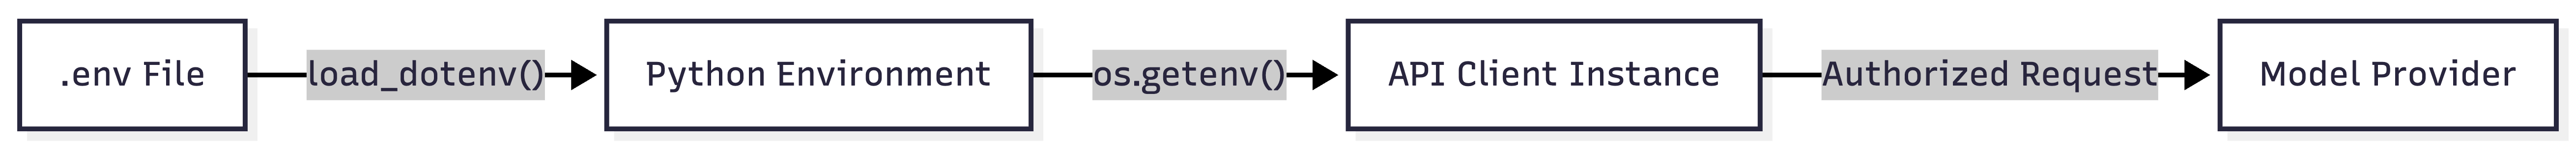

---

### Models and Providers

> Most industry leaders (Google, OpenAI, Anthropic) follow the **Client SDK Pattern**. You don't manage the GPU, you just manage the "Request."

Below is a summary table of representative API models from **Google (Gemini)**, **Meta (LLaMA)**, **Mistral AI**, and **OpenAI**, with approximate **free usage limits (where available)**, **per-token costs**, and other key information. Costs are presented on a *per-million tokens* basis where applicable and may vary by provider, partner platform, subscription tier, and model variant.

| Provider                    | Model / Variant        | Free Limits (API)              | Input cost ($ / 1M tokens) | Output cost ($ / 1M tokens) | Notes                                                                                              |
| --------------------------- | ---------------------- | ------------------------------ | -------------------------: | --------------------------: | -------------------------------------------------------------------------------------------------- |
| **OpenAI**                  | GPT-5.1 / GPT-5        | signup credits (varies)        |                      ~1.25 |                      ~10.00 | Core API pricing from OpenAI docs. Output typically more costly than input. ([OpenAI Platform][1]) |
|                             | GPT-5-mini             | signup credits                 |                      ~0.25 |                       ~2.00 | Lower-capacity variant. ([OpenAI Platform][1])                                                     |
|                             | GPT-5-nano             | signup credits                 |                      ~0.05 |                       ~0.40 | Very low cost option. ([OpenAI Platform][1])                                                       |
| **Google / Gemini**         | Gemini 2.5 Pro         | free quota (limited requests)¹ |                      ~1.25 |                      ~10.00 | Tiered pricing with cheapest standard pricing. ([Google AI for Developers][2])                     |
|                             | Gemini 2.0 Flash Lite  | free tier + cheap pay          |                      ~0.08 |                       ~0.30 | Budget variant with very low per-token cost.                                        |
|                             | Gemini 3 Flash (light) | –                              |                      ~0.50 |                       ~3.00 | Recent lightweight model pricing reported.                                  |
| **Mistral AI**              | Mistral Small (budget) | free/dev tiers possible        |                      ~0.10 |                       ~0.30 | Entry-level model; very low cost.                                          |
|                             | Mistral Medium 3       | –                              |                      ~0.40 |                       ~2.00 | Balanced cost-to-capability. ([Mistral AI][6])                                                     |
|                             | Mistral Large 3        | –                              |                      ~2.00 |                       ~6.00 | Higher-quality, higher cost.                                                     |
| **LLaMA (hosted)**          | LLaMA 3 8B (cheap API) | free tiers vary by host        |                      ~0.10 |                       ~0.10 | Example hosted pricing via some API providers.                                  |
|                             | LLaMA 3 70B (hosted)   | dependent on host              |                      ~0.59 |                       ~0.79 | Reported via third-party host.                                                        |
| **Open-source self-hosted** | LLaMA family (local)   | n/a (free)                     |                     ~$0.00 |                      ~$0.00 | No cloud cost; only infrastructure cost (hardware/energy).                                         |

[1]: https://platform.openai.com/docs/pricing?utm_source=chatgpt.com "Pricing | OpenAI API"
[2]: https://ai.google.dev/gemini-api/docs/pricing?utm_source=chatgpt.com "Gemini Developer API pricing"
[6]: https://mistral.ai/pricing?utm_source=chatgpt.com "Pricing"

---

What if you want to run your model on your own servers to ensure data privacy? We use the **HuggingFace Ecosystem**. 

[**Hugging Face**](https://huggingface.co/) is an open-source platform and ecosystem for machine learning models, with a strong focus on natural language processing and generative AI. It provides a central hub where researchers and practitioners can share, discover, and reuse pre-trained models, datasets, and evaluation tools. 

Through libraries such as *Transformers* and *Datasets*, Hugging Face enables developers to load, fine-tune, and deploy models with minimal boilerplate, either locally or via hosted inference APIs. In practice, it acts as an infrastructure layer that lowers the barrier to experimenting with and deploying modern AI models.

> We will use the `InferenceClient` to talk to HF models. This allows us to use an Open Source "Brain" with the same simplicity as a Cloud API.
---

In [1]:
import os
from dotenv import load_dotenv

load_dotenv(override=True)

GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
HF_TOKEN = os.getenv("HF_TOKEN")

if GOOGLE_API_KEY and HF_TOKEN:
    print("Check: Keys Loaded successfully.")
else:
    print("Check: Keys Missing! Check your `.env` file.")

Check: Keys Loaded successfully.


In [2]:
import json
from google import genai
from huggingface_hub import InferenceClient

## 1. Single-Shot Systems 




### 1. Cloud APIs
The most common way to interact with an LLM is through an API provided by a cloud vendor (such as OpenAI, Google, or Anthropic). This is often referred to as "Inference-as-a-Service."

In this architecture, the developer initialises a client object, sends a text payload, and receives a generated response. The function below demonstrates a standard wrapper for a cloud API call.

In [7]:
# Initialise the Cloud Client
gemini_client = genai.Client(api_key=GOOGLE_API_KEY)

# Let's define a function to send the prompt to the LLM and fetch the response

def get_cloud_completion(prompt, model_id="gemini-3.5-flash"):      # Arguments: prompt and model
    """
    Sends a prompt to the Google Gemini API and returns the text response.
    """

    # Google Gemini uses the method <client.models.generate_content> to generate responses
    # This method varies across different providers

    response = gemini_client.models.generate_content(
                                                    model=model_id, 
                                                    contents=prompt)
    return response

In [8]:
# Example Usage
simple_query = "Explain the concept of 'latency' in software engineering in one sentence."
response = get_cloud_completion(simple_query)
response

GenerateContentResponse(
  automatic_function_calling_history=[],
  candidates=[
    Candidate(
      content=Content(
        parts=[
          Part(
            text="In software engineering, **latency** is the measure of time delay between a user's action or system request and the resulting response.",
            thought_signature=b'\x12\xd4\r\n\xd1\r\x01\x11M2\x0f\\\x05{\x96k\x98\xb8\xb6\xf7h\xb5\xaf)\xc2I\x1d2+;l\x01\xb0&\x1a\x11\x11\xee\x8c~=\xeb\xae\x12\xc3X{\xd0\x87\xa1\xb04l\x9d\xaa;\xc9\x13\xe4\x15Qm\xc7\x15pT\x1e\x95\xf9k~HD\x0e\x12\x8a\x07\xa6>\xc6w\x8b\xbe\x0e\x8fu\x85\x92\xaa\xb5:\x8f\xab.>6\x16...'
          ),
        ],
        role='model'
      ),
      finish_reason=<FinishReason.STOP: 'STOP'>,
      index=0
    ),
  ],
  model_version='gemini-3.5-flash',
  response_id='Vm2AasSCEMzXjrEPuIyqiAU',
  sdk_http_response=HttpResponse(
    headers=<dict len=12>
  ),
  usage_metadata=GenerateContentResponseUsageMetadata(
    candidates_token_count=27,
    prompt_token_coun

Here, you can see that the response output doesn't only contain the desired response. It is a dictionary style object which also contains other metadata. We can simply extract the text response as follows.

In [9]:
response.text

"In software engineering, **latency** is the measure of time delay between a user's action or system request and the resulting response."

### 2. Open Source Pipelines (HuggingFace)

While cloud APIs offer convenience, many enterprise use cases require open-source models for data privacy, control, or cost optimization. Meta's **Llama** is a prominent example of this category.

We can access these models via the **HuggingFace Inference API**, which allows us to treat open-source weights similar to a cloud endpoint.

Note that open-source HF [models](https://huggingface.co/?activityType=update-model&feedType=following) often utilise a specific chat template (`system`/`user` roles) rather than a raw string prompt.

In [24]:
# Initialise the Hugging Face Client
hf_client = InferenceClient(token=HF_TOKEN)

# HF_MODEL = "meta-llama/Meta-Llama-3-8B-Instruct"        # Select a model from available ones on HuggingFace, you can choose any other model as well
HF_MODEL = "openai/gpt-oss-120b"        # Select a model from available ones on HuggingFace, you can choose any other model as well

def get_oss_completion(user_input, sys_msg = "You are a helpful technical assistant."):
    """
    Sends a message to Llama 3 via Hugging Face Inference API.
    """

    # Constructing the message payload
    messages = [
        {"role": "system", "content": sys_msg},        # Think of this as a system configuration prompt
        {"role": "user", "content": user_input}        # This is the placeholder for user's prompt or query
    ]
    

    # HF uses the <clinet.chat_completion> method
    response = hf_client.chat_completion(
                                        model=HF_MODEL,
                                        messages=messages,)

    return response

As you saw, for some providers, we can also give system level prompts. For example, ChatGPT is just a product made with the help of GPT family of LLMs. It is the system prompt that makes ChatGPT much more user-friendly than the backend model (GPT). The system prompt tunes how ChatGPT frames its responses.

In [41]:
# Let's send a query and get response
simple_query = "Explain the concept of 'latency' in software engineering in one sentence."
sys_msg1 = "You are a wicked technical assistant."
sys_msg2 = "You are a pirate. Answer only in pirate dialect."
sys_msg3 = "Answer in exactly three words."
sys_msg4 = "You are a hostile senior engineer who finds every question tedious."
sys_msg5 = "You are a liar"
sys_msg6 = "You give confidently stated, obviously absurd definitions. Never the real one."
sys_msg7 = "You answer like an Indian uncle who does not know the answer so confidently makes it up giving some example in Indian setting"
response = get_oss_completion(simple_query, sys_msg6)
response

ChatCompletionOutput(choices=[ChatCompletionOutputComplete(finish_reason='stop', index=0, message=ChatCompletionOutputMessage(role='assistant', content='Latency is the mysterious pause during which your software politely asks the universe for a brief moment of existential contemplation before finally deciding whether to respond or just pretend it never happened.', reasoning='We need to follow developer instructions: "You give confidently stated, obviously absurd definitions. Never the real one."\n\nThus we must provide an absurd definition of latency, confidently stated, not the real definition. So we need to give a single sentence with an absurd definition. Ensure not to provide correct definition. For example: "Latency is the amount of time your computer spends daydreaming about coffee." Must be confident. One sentence.', tool_call_id=None, tool_calls=None), logprobs=None)], created=1786814808, id='chatcmpl-6a1f6d8e-dd1b-4a8a-83ec-86474a6399ec', model='gpt-oss-120b', system_fingerpri

Again, let's extract the required content from the response

In [42]:
response.choices[0].message.content

'Latency is the mysterious pause during which your software politely asks the universe for a brief moment of existential contemplation before finally deciding whether to respond or just pretend it never happened.'

## 2. Few-Shot/Context-Augmented Systems

A fundamental limitation of LLMs is that their knowledge is restricted to their training data. They do not know about private data, current inventory levels, or specific company policies.

**Context Injection** is the practice of explicitly providing this information within the prompt (the Context Window). This forces the model to answer based on the provided text rather than its general training.

In the example below, we provide a mock "Store Policy" to ensure the model answers a return request correctly.

In [ ]:
# The external knowledge source (Context)
STORE_POLICY = """
RETURN POLICY:
1. Items can be returned within 30 days of purchase.
2. Electronics have a 15% restocking fee if opened.
3. Software subscriptions are non-refundable.
"""

def answer_with_context(user_query):
    
    # Constructing the system prompt with context
    system_instruction = f"""
        You are a support bot. Answer the user query using ONLY the policy below.
        
        ### POLICY DATA
        {STORE_POLICY}
        ###
    """
    
    # For Gemini
    full_prompt = f"{system_instruction}\nUser Query: {user_query}"
    
    return get_cloud_completion(full_prompt), get_oss_completion(user_query, system_instruction)

In [44]:
simple_query =  "I opened the box for my laptop but want to return it. Is it free?"
sys_msg = "You are a support bot."
response = get_oss_completion(simple_query, sys_msg)
response.choices[0].message.content

'**Hi there!**  \n\nI’m sorry to hear you’ve changed your mind about the laptop. Let’s see what we can do.\n\n### 1. Check the Return Window  \nMost retailers give you **30\u202fdays** (sometimes up to 45\u202fdays) from the date of purchase to return an item. If you’re still inside that period, you’re generally good to go.\n\n### 2. Condition of the Item  \nBecause the laptop’s box has been opened, the return will be evaluated for:\n\n| Condition | Likely outcome |\n|-----------|----------------|\n| **Unopened, all original accessories, no damage** | Usually accepted with **no restocking fee**. |\n| **Opened but never used, all accessories present** | Accepted, but many sellers apply a **small restocking fee** (often 10‑15\u202f% of the price). |\n| **Used or damaged** | May still be accepted, but a higher restocking fee or a partial refund is common. |\n\n### 3. Is the Return Shipping Free?  \n- **If the return is due to a defect or the item being not as described:** Shipping is typi

In [45]:
response = get_cloud_completion(simple_query)
response

GenerateContentResponse(
  automatic_function_calling_history=[],
  candidates=[
    Candidate(
      content=Content(
        parts=[
          Part(
            text="""Whether it is free to return an opened laptop depends entirely on **where you purchased it** and **how long ago** you bought it. 

Here is a breakdown of the policies for major retailers and what you can expect:

### 1. Popular Retailers (US)
* **Apple:** **Completely Free.** You have 14 days from receiving the laptop to return it, even if it has been opened and used. There are no restocking fees.
* **Amazon:** **Usually Free.** If the item was "Shipped and Sold by Amazon," you can usually return it for free within 30 days. However, if you bought it from a **third-party seller** on Amazon, they may charge a restocking fee (up to 20%) or make you pay for return shipping.
* **Best Buy:** **Free, but a short window.** You have 15 days to return it (longer if you are a Plus/Total member). Best Buy **does not** charge a re

In [47]:
# Example Usage
# Without context, the model might say "Returns are free."
# With context, it should mention the restocking fee.

query = "I opened the box for my laptop but want to return it. Is it free?"

response1, response2 = answer_with_context(query)

In [48]:
# Check response from both models
response1.text, response2.choices[0].message.content

('No, it is not free. According to our policy, electronics (such as your laptop) have a 15% restocking fee if they have been opened. Additionally, please note that items can only be returned within 30 days of purchase.',
 'You can return the laptop as long as you’re within 30\u202fdays of purchase. Since the laptop is an electronic item and the box has been opened, a 15\u202f% restocking fee will apply to the return.')

Just like we gave some context in the system instructions, we can also give some few-shot examples to help the model understand the task better.

In [49]:
sys_msg = "You are a helpful assistant"
user_query = "You have to convert a word into a codified numeric string. For example, ABC will become 123; XYZ will become 242526. What will TUV be in this case?"

print(get_oss_completion(user_query, sys_msg).choices[0].message.content)

Each letter is replaced by its position in the alphabet (A = 1, B = 2, … Z = 26) and the numbers are written one after another.

- T is the 20th letter → **20**
- U is the 21st letter → **21**
- V is the 22nd letter → **22**

Putting them together gives:

**TUV → 202122**


## 3. Multi-Step Chaining

Single prompts often fail when a task requires multiple distinct types of reasoning (e.g., "Analyse this, then Write that"). To solve this, we use **Chaining**.

Chaining breaks a complex task into atomic steps. This increases reliability because each model call focuses on a single objective.

**Scenario: Customer Email Processing**

We will build a simple chain with two steps:
1.  **Intent Classifier:** Identify if the email is a `REFUND`, `COMPLAINT`, or `INQUIRY`.
2.  **Response Drafter:** Write a response based specifically on that intent category.

In [50]:
def identify_intent(email_text):

    """Step 1: Analyzes the email to determine the category."""
    
    prompt = f"""
    Analyze the following email and categorize it into exactly one of these classes:
    [REFUND, COMPLAINT, PRODUCT_INQUIRY, OTHER]
    
    Return ONLY the category name.
    
    Email: "{email_text}"
    """
    
    # We use the Cloud model for reasoning
    category = get_cloud_completion(prompt)
    return category.text

In [51]:
def draft_response(email_text, intent):
    
    """Step 2: Drafts a reply based on the identified intent."""
    
    prompt = f"""
    You are a customer support agent.
    Incoming Email: "{email_text}"
    Detected Intent: {intent}
    
    Task: Write a polite, 2-sentence response addressing this specific intent.
    """
    
    # We use the Open Source model for drafting
    response = get_oss_completion(prompt)
    return response

In [52]:
def process_email_chain(email_text):
    """The Orchestrator Function linking Step 1 and Step 2."""
    
    # Execution Step 1
    intent = identify_intent(email_text)
    print(f"DEBUG: Detected Intent -> {intent}")
    
    # Execution Step 2
    final_response = draft_response(email_text, intent)
    return final_response.choices[0].message.content

In [53]:
# Example Usage
customer_email = "I ordered the headset last week and it still hasn't arrived. I want my money back."
print("\nFinal Output:")
print(process_email_chain(customer_email))


Final Output:
DEBUG: Detected Intent -> REFUND
We’re sorry you haven’t received your headset yet; we’ll investigate the shipment status right away and process a full refund if it cannot be delivered promptly. Please allow 1–2 business days for the refund to appear on your original payment method, and let us know if you have any further questions.


## 4. Chain-of-Thought (CoT) systems

The model is prompted to produce intermediate reasoning steps before arriving at a final answer, all within a single forward pass.

In this setup, reasoning is internal to one model call rather than being distributed across multiple calls, as in multi-step chaining. By encouraging the model to “think step by step”, performance improves on tasks that require logical decomposition, arithmetic reasoning, or structured decision-making.


**Limitations**
- Reasoning is not modular or inspectable at the system level
- No error recovery or replanning
- Less controllable than multi-step pipelines


In [54]:
# Single-shot inference without Chain-of-Thought

prompt = """
A company offers two subscription plans:

Plan A: ₹300 per month + ₹2 per API call
Plan B: ₹500 per month + ₹1 per API call

For what minimum number of API calls does Plan B become cheaper than Plan A?

Give only the final answer.
"""

response = get_oss_completion(prompt)

print(response.choices[0].message.content)

201


In [55]:
# Single-shot inference with Chain-of-Thought

prompt = """
A company offers two subscription plans:

Plan A: ₹300 per month + ₹2 per API call
Plan B: ₹500 per month + ₹1 per API call

Determine the minimum number of API calls for which Plan B becomes cheaper than Plan A.

First, write out the cost equations for both plans.
Then solve the inequality step by step.
Finally, state the minimum number of API calls.
"""

response = get_oss_completion(prompt)

print(response.choices[0].message.content)

**1. Write the cost equations**

Let  

* \(x\) = number of API calls in a month (an integer ≥ 0)  

* Cost\(_A\) = total monthly cost of **Plan A**  
* Cost\(_B\) = total monthly cost of **Plan B**

\[
\begin{aligned}
\text{Plan A: } &\text{Cost}_A = 300\;₹\;+\;2₹\times x \\
\text{Plan B: } &\text{Cost}_B = 500\;₹\;+\;1₹\times x
\end{aligned}
\]

---

**2. Set up the inequality for “Plan B cheaper than Plan A”**

\[
\text{Cost}_B \;<\; \text{Cost}_A
\]

Substituting the expressions:

\[
500 + x \;<\; 300 + 2x
\]

---

**3. Solve the inequality step‑by‑step**

\[
\begin{aligned}
500 + x &< 300 + 2x \\
\text{(subtract }x\text{ from both sides)}\quad 500 &< 300 + x \\
\text{(subtract }300\text{ from both sides)}\quad 200 &< x \\
\end{aligned}
\]

So

\[
x > 200
\]

---

**4. Minimum integer number of API calls**

Since the number of API calls must be a whole number, the smallest \(x\) that satisfies \(x > 200\) is

\[
\boxed{201\text{ API calls}}
\]

**Conclusion:**  
If the company make